In [2]:
import warnings
warnings.filterwarnings("ignore")

In [1]:
import os
import json
from pathlib import Path
from tqdm import tqdm

from PIL import Image
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np

import torch
from diffusers import StableDiffusionPipeline

/usr/local/lib/python3.10/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

In [3]:
CONCEPT = 'apple'

# 프롬프트마다 NUM_IMAGES_PER_PROMPT장 생성
PROMPTS = [
    f"a photo of an {CONCEPT}",
]
PROMPT = PROMPTS[0]  # 단일 프롬프트 쓰는 셀 호환용

NUM_PROMPTS = len(PROMPTS)
NUM_IMAGES_PER_PROMPT = 100
NUM_IMAGES_TOTAL = NUM_PROMPTS * NUM_IMAGES_PER_PROMPT

SEED_BASE = 1000
TARGET_BLOCK = 'up_blocks.1.attentions.1.transformer_blocks.0.ff.net.0'
INJECT_BLOCK = 'up_blocks.1'

NUM_INFERENCE_STEPS = 50
CAPTURE_STEP = 10
GUIDANCE_SCALE = 7.5
NEGATIVE_PROMPT = ""
TOP_K = 100
ETA = 0.0


def prompt_dir_name(prompt_idx: int, prompt: str) -> str:
    slug = prompt.lower().replace(" ", "_").replace("/", "_")[:40]
    return f"prompt_{prompt_idx:02d}_{slug}"


In [4]:
if "pipe" not in globals():
    pipe = StableDiffusionPipeline.from_pretrained("runwayml/stable-diffusion-v1-5")
    pipe = pipe.to(DEVICE)
    pipe.safety_checker = None
    pipe.set_progress_bar_config(disable=True)

In [5]:
# 타겟 블록 탐색
def get_target_block(unet, target_block_name: str):
    parts = target_block_name.split(".")
    def resolve(obj, remaining):
        if not remaining:
            return obj
        part, *rest = remaining
        child = obj[int(part)] if part.isdigit() else getattr(obj, part)
        return resolve(child, rest)
    return resolve(unet, parts)


# 배치 조건 확인
def _tensor_cond_batch_slice(t: torch.Tensor) -> torch.Tensor:
    if t.dim() >= 1 and t.shape[0] >= 2:
        return t[1]
    return t[0]

def _capture_activation(x):
    if isinstance(x, torch.Tensor):
        return _tensor_cond_batch_slice(x).clone().detach().cpu()
    if isinstance(x, (tuple, list)):
        tensors = [
            _tensor_cond_batch_slice(t).clone().detach().cpu()
            for t in x
            if isinstance(t, torch.Tensor)
        ]
        if len(tensors) == 1:
            return tensors[0]
        return tensors
    return x


# 특정 step에서 activation input/output 저장 - 일단 input만 사용할거야
def make_forward_activation_hook_at_step(capture_step: int):
    state = {"forward_i": -1, "value": None}
    
    def hook(module, input, output):
        state["forward_i"] += 1
        if state["forward_i"] != capture_step:
            return
        state["value"] = {
            "input": _capture_activation(input),
            "output": _capture_activation(output),
        }

    return hook, state

In [6]:
def save_up1_activations(up1_acts_per_image, save_dir: Path, *, meta: dict | None = None) -> Path:
    block_dir = Path(save_dir) / "up_blocks_1"
    block_dir.mkdir(parents=True, exist_ok=True)

    # RAM-safe path: write .npy memmap directly
    if isinstance(up1_acts_per_image, np.ndarray):
        stacked = up1_acts_per_image.astype(np.float32, copy=False)
    else:
        sample = np.asarray(up1_acts_per_image[0], dtype=np.float32)
        stacked = np.lib.format.open_memmap(
            block_dir / "act_maps_n_t_h_w.npy",
            mode="w+",
            dtype=np.float32,
            shape=(len(up1_acts_per_image), *sample.shape),
        )
        for i, arr in enumerate(up1_acts_per_image):
            stacked[i] = np.asarray(arr, dtype=np.float32)
        stacked.flush()

    payload_meta = {
        "seed_base": SEED_BASE,
        "block": INJECT_BLOCK,
        "num_inference_steps": NUM_INFERENCE_STEPS,
        "shape": list(stacked.shape),
        "format": "npy_memmap",
        **(meta or {}),
    }
    with open(block_dir / "meta.json", "w", encoding="utf-8") as f:
        json.dump(payload_meta, f, indent=2, ensure_ascii=False)

    print(f"  up_blocks.1 acts: {tuple(stacked.shape)} → {block_dir / 'act_maps_n_t_h_w.npy'}")
    return block_dir

In [7]:
def save_capture_run(
    images,
    activations_per_image,
    block_name: str,
    save_dir: Path,
    *,
    meta: dict | None = None,
) -> Path:
    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)
    images_dir = save_dir / "images"
    images_dir.mkdir(exist_ok=True)
    block_dir = save_dir / block_name.replace(".", "_")
    block_dir.mkdir(exist_ok=True)
    payload_meta = {
        "negative_prompt": NEGATIVE_PROMPT,
        "seed_base": SEED_BASE,
        "num_images": len(images),
        "target_block": TARGET_BLOCK,
        "num_inference_steps": NUM_INFERENCE_STEPS,
        "capture_step": CAPTURE_STEP,
        "guidance_scale": GUIDANCE_SCALE,
        **(meta or {}),
    }
    inputs_list, outputs_list = [], []
    for i, act in enumerate(activations_per_image):
        if act is None:
            raise ValueError(f"activations_per_image[{i}] is None")
        inputs_list.append(act["input"])
        outputs_list.append(act["output"])
        images[i].save(images_dir / f"{i:04d}.png")
    inputs_stacked = torch.stack(inputs_list)
    outputs_stacked = torch.stack(outputs_list)
    torch.save(
        {"inputs": inputs_stacked, "outputs": outputs_stacked},
        block_dir / "activations.pt",
    )
    with open(block_dir / "meta.json", "w", encoding="utf-8") as f:
        json.dump(payload_meta, f, indent=2, ensure_ascii=False)
    print(f"saved → {save_dir}")
    print(f"  images: {len(images)} | activations: {inputs_stacked.shape}")
    return save_dir


In [8]:
# generator = torch.Generator(device="cpu")

# ff_block = get_target_block(pipe.unet, TARGET_BLOCK)
# inject_module = get_target_block(pipe.unet, INJECT_BLOCK)

# capture_hook, capture_state = make_forward_activation_hook_at_step(CAPTURE_STEP)
# up1_state = {"acts": []}

# def up1_capture_hook(_module, _inputs, output):
#     out = output[0] if isinstance(output, tuple) else output
#     feat = out[1] if out.shape[0] > 1 else out[0]
#     up1_state["acts"].append(feat.detach().float().cpu().numpy().astype(np.float32))

# ff_handle = ff_block.register_forward_hook(capture_hook)
# up1_handle = inject_module.register_forward_hook(up1_capture_hook)

# SAVE_DIR = Path(f"/project/dam/data/{CONCEPT}")
# SAVE_DIR.mkdir(parents=True, exist_ok=True)

# for p_idx, prompt in enumerate(PROMPTS):
#     images, activations_per_image = [], []
#     up1_memmap = None
#     up1_shape = None
#     pdir = SAVE_DIR / prompt_dir_name(p_idx, prompt)

#     for i in tqdm(range(NUM_IMAGES_PER_PROMPT), desc=f"prompt {p_idx}: {prompt[:40]}..."):
#         global_idx = p_idx * NUM_IMAGES_PER_PROMPT + i
#         seed = SEED_BASE + global_idx
#         generator.manual_seed(seed)

#         capture_state["forward_i"] = -1
#         capture_state["value"] = None
#         up1_state["acts"] = []

#         result = pipe(
#             prompt=prompt,
#             negative_prompt=NEGATIVE_PROMPT,
#             num_inference_steps=NUM_INFERENCE_STEPS,
#             guidance_scale=GUIDANCE_SCALE,
#             num_images_per_prompt=1,
#             generator=generator,
#             output_type="pil",
#         )
#         img = result["images"][0] if isinstance(result, dict) else result.images[0]
#         images.append(img)
#         activations_per_image.append(capture_state["value"])
#         up1_arr = np.stack(up1_state["acts"], axis=0).astype(np.float32)
#         if up1_memmap is None:
#             up1_shape = up1_arr.shape
#             up1_dir = pdir / "up_blocks_1"
#             up1_dir.mkdir(parents=True, exist_ok=True)
#             up1_memmap = np.lib.format.open_memmap(
#                 up1_dir / "act_maps_n_t_h_w.npy",
#                 mode="w+",
#                 dtype=np.float32,
#                 shape=(NUM_IMAGES_PER_PROMPT, *up1_shape),
#             )
#         up1_memmap[i] = up1_arr
#         if (i + 1) % 25 == 0:
#             up1_memmap.flush()

#     save_capture_run(
#         images,
#         activations_per_image,
#         TARGET_BLOCK.replace(".", "_"),
#         pdir,
#         meta={"prompt": prompt, "prompt_idx": p_idx},
#     )
#     if up1_memmap is not None:
#         up1_memmap.flush()
#     save_up1_activations(
#         up1_memmap if up1_memmap is not None else [],
#         pdir,
#         meta={"prompt": prompt, "prompt_idx": p_idx},
#     )

# ff_handle.remove()
# up1_handle.remove()

# with open(SAVE_DIR / "prompts.json", "w", encoding="utf-8") as f:
#     json.dump(
#         {
#             "prompts": PROMPTS,
#             "num_images_per_prompt": NUM_IMAGES_PER_PROMPT,
#             "seed_base": SEED_BASE,
#         },
#         f,
#         indent=2,
#         ensure_ascii=False,
#     )
# print(f"done: {NUM_PROMPTS} prompts × {NUM_IMAGES_PER_PROMPT} images → {SAVE_DIR}")

In [9]:
def load_up1_maps(pdir: Path):
    npz_path = pdir / "up_blocks_1" / "act_maps_n_t_h_w.npz"
    npy_path = pdir / "up_blocks_1" / "act_maps_n_t_h_w.npy"
    if npy_path.exists():
        return np.load(npy_path, mmap_mode="r")
    if npz_path.exists():
        return np.load(npz_path)["act_maps_n_t_h_w"]
    raise FileNotFoundError(f"No up1 maps found in {pdir / 'up_blocks_1'}")

# 전체 프롬프트 로드
SAVE_DIR = Path(f"/project/dam/data/{CONCEPT}")

images, inputs_list, up1_list = [], [], []
prompt_index = []

for p_idx, prompt in enumerate(PROMPTS):
    pdir = SAVE_DIR / prompt_dir_name(p_idx, prompt)
    n = NUM_IMAGES_PER_PROMPT
    images.extend([Image.open(pdir / "images" / f"{i:04d}.png") for i in range(n)])
    inputs_list.append(
        torch.load(pdir / TARGET_BLOCK.replace(".", "_") / "activations.pt")["inputs"].cpu()
    )
    up1_list.append(
        load_up1_maps(pdir)
    )
    prompt_index.extend([p_idx] * n)

inputs = torch.cat(inputs_list, dim=0)
up1_all = np.concatenate(up1_list, axis=0)

prompt_index = np.array(prompt_index, dtype=np.int32)
N = len(images)

inputs.shape, up1_all.shape, prompt_index.shape

(torch.Size([100, 256, 1280]), (100, 51, 1280, 32, 32), (100,))

\begin{aligned}
&\text{직선의 방정식} \\
&w_1 x + w_2 y + b_i = 0 \\
&⇒ w_2 y = -(w_1 x + b_i) \\
&⇒ y = -\frac{w_1 x + b_i}{w_2}
\end{aligned}

In [10]:
# weight & bias 추출
ff = get_target_block(pipe.unet, TARGET_BLOCK)
ff_state = ff.state_dict()

W_geglu = ff_state["proj.weight"].cpu().float()   # (10240, 1280)
n_geglu_half = W_geglu.shape[0] // 2

W2 = W_geglu[n_geglu_half:]
b_geglu = ff_state["proj.bias"].cpu().float()
b2 = b_geglu[n_geglu_half:]

In [11]:
# inputs: (N, 256, 1280) — 이미지마다 mean_map·similarity·top-k를 각각 계산
N, seq_len, dim = inputs.shape
side = int(seq_len ** 0.5)
assert side * side == seq_len

K = 100 # 추출한 주요 뉴런 수

# (N, side, side, dim) → spatial mean → (N, seq_len)
h_3d = inputs.reshape(N, side, side, dim)
mean_map = h_3d.mean(dim=-1).reshape(N, seq_len)  # (N, 256)

# h: (N, 256, 1280) @ W2.T: (1280, 5120) → (N, 256, 5120)
neuron_acts = inputs @ W2.T

# spatial mean과의 유사도
similarity = (neuron_acts * mean_map.unsqueeze(-1)).sum(dim=1)  # (N, 5120)

similarity_mean = similarity.mean(dim=0)  # (5120,)
top_k_idx = similarity_mean.topk(K).indices  # 0~5119 범위

In [12]:
# w & b도 해당 뉴런들만 추출
W2_topk = W2[top_k_idx, :]
b2_topk = b2[top_k_idx]

print(W2_topk.shape, b2_topk.shape)

torch.Size([100, 1280]) torch.Size([100])


In [13]:
# 각 토큰이 hyperplane에서 얼마나 떨어져 있는지
signed_dist = inputs @ W2_topk.T
signed_dist = signed_dist + b2_topk
signed_dist = signed_dist / W2_topk.norm(dim=-1)

signed_dist.shape

torch.Size([100, 256, 100])

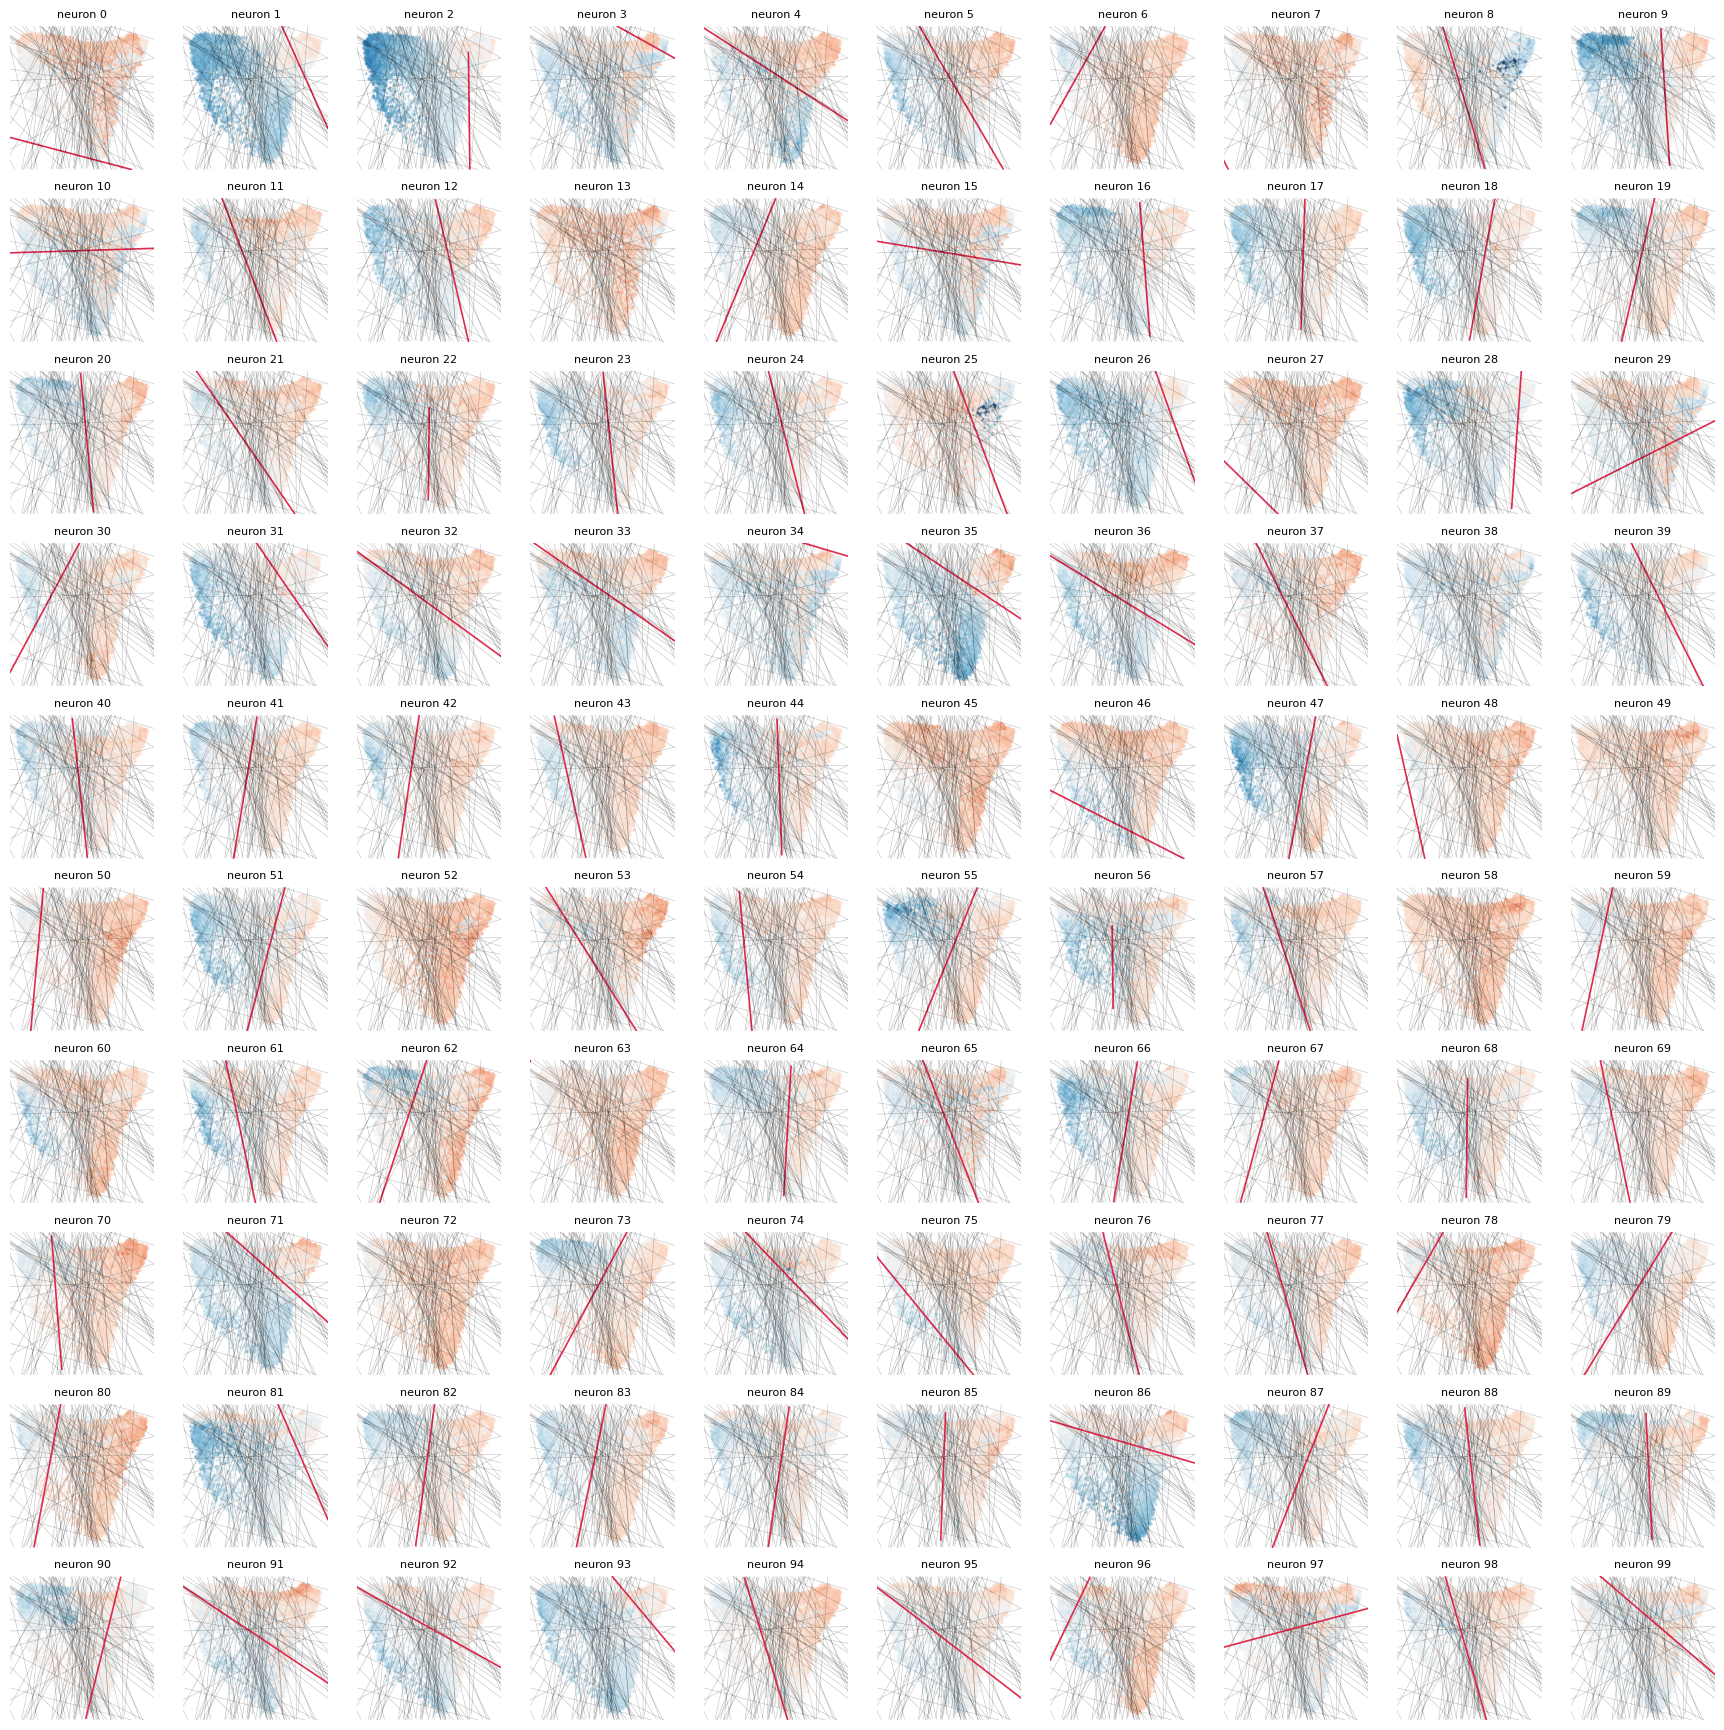

PCA explained variance: [0.15610714 0.07296233]
교점 수: 2368


In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# 1. PCA
h_all = inputs.reshape(-1, inputs.shape[-1]).cpu().numpy()
pca_act = PCA(n_components=2)
h_2d = pca_act.fit_transform(h_all)

# 범주
x_min, x_max = h_2d[:, 0].min(), h_2d[:, 0].max()
y_min, y_max = h_2d[:, 1].min(), h_2d[:, 1].max()
pad = 0.05
x_lim = (x_min - pad*(x_max-x_min), x_max + pad*(x_max-x_min))
y_lim = (y_min - pad*(y_max-y_min), y_max + pad*(y_max-y_min))
x_range = np.linspace(x_lim[0], x_lim[1], 300)

# 2. w_j, b_j를 PCA 공간으로 변환
def to_2d(w_j, b_j):
    w_2d = pca_act.components_ @ w_j.cpu().numpy()
    b_2d = float(w_j.cpu().numpy() @ pca_act.mean_) + float(b_j)
    return w_2d, b_2d

# 3. 교점 계산
intersections = []
for i in range(K):
    for j in range(i+1, K):
        w_2d_i, b_2d_i = to_2d(W2_topk[i], b2_topk[i])
        w_2d_j, b_2d_j = to_2d(W2_topk[j], b2_topk[j])

        A = np.array([w_2d_i, w_2d_j])
        b = np.array([-b_2d_i, -b_2d_j])

        if abs(np.linalg.det(A)) < 1e-8:
            continue

        pt = np.linalg.solve(A, b)
        if x_lim[0] < pt[0] < x_lim[1] and y_lim[0] < pt[1] < y_lim[1]:
            intersections.append(pt)

intersections = np.array(intersections) if intersections else np.zeros((0, 2))

# 4. 시각화 — 뉴런 k마다
sd_flat = signed_dist.reshape(-1, K).cpu().numpy()

w_2d_all, b_2d_all = [], []
for j in range(K):
    w, b = to_2d(W2_topk[j], b2_topk[j])
    w_2d_all.append(w)
    b_2d_all.append(b)

ncols = 10
nrows = int(np.ceil(K / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(2.2 * ncols, 2.2 * nrows), squeeze=False)
axes_flat = axes.flatten()

def _plot_boundary(ax, w_2d, b_2d, *, lw=0.5, alpha=0.3, color='k'):
    if abs(w_2d[1]) < 1e-8:
        if abs(w_2d[0]) > 1e-8:
            x0 = -b_2d / w_2d[0]
            if x_lim[0] <= x0 <= x_lim[1]:
                ax.axvline(x0, color=color, lw=lw, alpha=alpha)
        return
    y_line = -(w_2d[0] * x_range + b_2d) / w_2d[1]
    mask = (y_line >= y_lim[0]) & (y_line <= y_lim[1])
    if mask.any():
        ax.plot(x_range[mask], y_line[mask], '-', color=color, lw=lw, alpha=alpha)

for k, ax in enumerate(axes_flat[:K]):
    sc = ax.scatter(
        h_2d[:, 0], h_2d[:, 1],
        c=sd_flat[:, k], cmap='RdBu', s=2, alpha=0.35, vmin=-3, vmax=3,
    )
    for j in range(K):
        if j == k:
            _plot_boundary(ax, w_2d_all[j], b_2d_all[j], lw=1.2, alpha=0.9, color='crimson')
        else:
            _plot_boundary(ax, w_2d_all[j], b_2d_all[j], lw=0.4, alpha=0.25, color='k')
    ax.set_xlim(x_lim)
    ax.set_ylim(y_lim)
    ax.axis('off')
    ax.set_title(f'neuron {k}', fontsize=8)
    ax.tick_params(labelsize=6)

for ax in axes_flat[K:]:
    ax.axis('off')

plt.show()

print('PCA explained variance:', pca_act.explained_variance_ratio_)
print('교점 수:', len(intersections))

# 구분

In [ ]:
# # 두 이미지를 골라(h0, h1), h0은 각 hyperplane(z1)에, h1은 다른 hyperplane(z2)에 각각 정사영시켜
# # 모든 (z1, z2) 쌍 중 정사영점 사이 거리가 가장 큰 쌍을 찾기

# idx0 = 6   # 첫 이미지 인덱스 (임의로 선택, 필요시 변경)
# idx1 = 95  # 두 번째 이미지 인덱스 (임의로 선택, 필요시 변경)
# h0 = inputs[idx0].mean(dim=0).cpu()
# h1 = inputs[idx1].mean(dim=0).cpu()


# # 모든 쌍 (i, j)에 대해 h0을 i번 평면에, h1을 j번 평면에 정사영시킨 뒤 거리 측정
# max_dist = -1
# max_pair = None
# best_proj_h0 = None
# best_proj_h1 = None

# for i in range(K):
#     w_i = W2_topk[i].cpu()
#     b_i = b2_topk[i].cpu()
#     # h0의 i번 평면 정사영
#     offset0 = (w_i @ h0 + b_i) / (w_i @ w_i)
#     p0 = h0 - offset0 * w_i
#     for j in range(K):
#         w_j = W2_topk[j].cpu()
#         b_j = b2_topk[j].cpu()
#         # h1의 j번 평면 정사영
#         offset1 = (w_j @ h1 + b_j) / (w_j @ w_j)
#         p1 = h1 - offset1 * w_j
#         dist = (p0 - p1).norm().item()
#         if dist > max_dist:
#             max_dist = dist
#             max_pair = (i, j)
#             best_proj_h0 = p0
#             best_proj_h1 = p1

# print(f"가장 멀리 떨어진 정사영 쌍: h0 (plane {max_pair[0]}), h1 (plane {max_pair[1]}), distance = {max_dist:.3f}")

# # 필요하면 최상위 topk쌍 구하기
# topk = 10 if K > 10 else K

# # 거리와 쌍을 저장
# dists_pairs = []
# for i in range(K):
#     w_i = W2_topk[i].cpu()
#     b_i = b2_topk[i].cpu()
#     offset0 = (w_i @ h0 + b_i) / (w_i @ w_i)
#     p0 = h0 - offset0 * w_i
#     for j in range(K):
#         w_j = W2_topk[j].cpu()
#         b_j = b2_topk[j].cpu()
#         offset1 = (w_j @ h1 + b_j) / (w_j @ w_j)
#         p1 = h1 - offset1 * w_j
#         dist = (p0 - p1).norm().item()
#         dists_pairs.append(((i, j), dist))

# dists_pairs.sort(key=lambda x: -x[1])
# for idx, (pair, dist) in enumerate(dists_pairs[:topk]):
#     i, j = pair
#     print(f"Top {idx+1}: h0 (plane {i}), h1 (plane {j})  distance = {dist:.3f}")

가장 멀리 떨어진 정사영 쌍: h0 (plane 78), h1 (plane 58), distance = 7.514
Top 1: h0 (plane 78), h1 (plane 58)  distance = 7.514
Top 2: h0 (plane 45), h1 (plane 58)  distance = 7.513
Top 3: h0 (plane 45), h1 (plane 27)  distance = 7.511
Top 4: h0 (plane 45), h1 (plane 80)  distance = 7.511
Top 5: h0 (plane 78), h1 (plane 80)  distance = 7.510
Top 6: h0 (plane 78), h1 (plane 45)  distance = 7.508
Top 7: h0 (plane 78), h1 (plane 27)  distance = 7.508
Top 8: h0 (plane 72), h1 (plane 58)  distance = 7.508
Top 9: h0 (plane 52), h1 (plane 58)  distance = 7.507
Top 10: h0 (plane 60), h1 (plane 58)  distance = 7.507


## 두 hyperplane 위 임의의 두 점을 잡고 직선을 그었을 때, 다른 hyperplane들과 만나는 교점 찾기

In [16]:
# # images에 있는 첫 100개 이미지를 10x10 그리드로 시각화
# import matplotlib.pyplot as plt

# n_images = 100
# n_row, n_col = 10, 10

# fig, axes = plt.subplots(n_row, n_col, figsize=(20, 20))
# for idx in range(n_images):
#     ax = axes[idx // n_col, idx % n_col]
#     img = images[idx]
#     if hasattr(img, 'permute'):  # torch.Tensor
#         img_disp = img.permute(1,2,0).cpu().numpy()
#     else:  # PIL Image or numpy array
#         img_disp = np.array(img)
#     ax.imshow(img_disp)
#     ax.axis('off')

# plt.tight_layout()
# plt.show()

In [33]:
j1 = 78   # 첫 번째 hyperplane
j2 = 58   # 두 번째 hyperplane

# base point
h0 = inputs[6].mean(dim=0).cpu()    # image 6
h1 = inputs[95].mean(dim=0).cpu()   # image 95

# A: h0를 hyperplane j1 위로 정사영
w_j1, b_j1 = W2_topk[j1].cpu(), b2_topk[j1].cpu()
offset_A = (w_j1 @ h0 + b_j1) / (w_j1 @ w_j1)
A = h0 - offset_A * w_j1

# B: h0를 hyperplane j2 위로 정사영
w_j2, b_j2 = W2_topk[j2].cpu(), b2_topk[j2].cpu()
offset_B = (w_j2 @ h1 + b_j2) / (w_j2 @ w_j2)
B = h1 - offset_B * w_j2

# 방향벡터
AB = B - A
ab_len = AB.norm().item()
d = AB / ab_len
print(f'|AB| = {ab_len:.3f}')

|AB| = 7.514


In [32]:
# j1 = 78   # 첫 번째 hyperplane
# j2 = 58   # 두 번째 hyperplane

# # base point
# h0 = inputs.mean(dim=(0, 1)).cpu()

# # A: h0를 hyperplane j1 위로 정사영
# w_j1, b_j1 = W2_topk[j1].cpu(), b2_topk[j1].cpu()
# offset_A = (w_j1 @ h0 + b_j1) / (w_j1 @ w_j1)
# A = h0 - offset_A * w_j1

# # B: h0를 hyperplane j2 위로 정사영
# w_j2, b_j2 = W2_topk[j2].cpu(), b2_topk[j2].cpu()
# offset_B = (w_j2 @ h0 + b_j2) / (w_j2 @ w_j2)
# B = h0 - offset_B * w_j2

# # 방향벡터
# AB = B - A
# d = AB / AB.norm()
# print(f'|AB| = {AB.norm():.3f}')

In [34]:
denom = W2_topk.cpu() @ d                       # (K,)
numer = -(W2_topk.cpu() @ A + b2_topk.cpu())    # (K,)

alphas_intersection = []
distances_intersection = []
neuron_ids = []

for i in range(K):
    if abs(denom[i].item()) < 1e-8:
        continue
    dist = (numer[i] / denom[i]).item()         # A로부터의 유클리드 거리
    if 0.0 <= dist <= ab_len:                     # A~B 선분 안에 있는 것만
        alphas_intersection.append(dist / ab_len) # 정규화 α ∈ [0, 1]
        distances_intersection.append(dist)
        neuron_ids.append(i)

alphas = np.array(alphas_intersection)
distances = np.array(distances_intersection)
print(f'alphas: {len(alphas)}개')

alphas: 6개


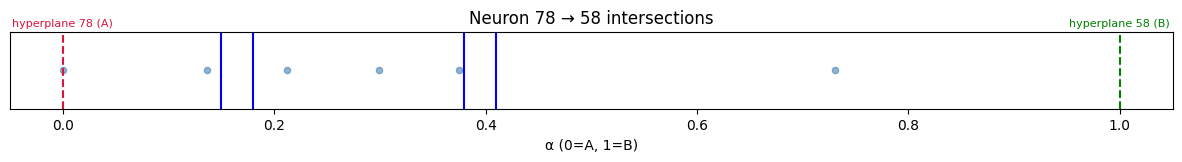

In [ ]:
# dense/sparse 구간 (정규화 α)
dense_alpha = (0.15, 0.18)
sparse_alpha = (0.38, 0.41)

# --- 정규화 α 축 ---
fig, ax = plt.subplots(figsize=(15, 1))
ax.scatter(alphas, np.zeros_like(alphas), s=20, color='steelblue', alpha=0.6)
ax.axvline(0, color='crimson', lw=1.5, linestyle='--')
ax.axvline(1, color='green',   lw=1.5, linestyle='--')
y_offset = 0.06
ax.text(0, y_offset, f'hyperplane {j1} (A)', color='crimson', ha='center', va='bottom', fontsize=8, clip_on=False)
ax.text(1, y_offset, f'hyperplane {j2} (B)', color='green', ha='center', va='bottom', fontsize=8, clip_on=False)
for a in dense_alpha:  ax.axvline(a, color='blue', lw=1.5)
for a in sparse_alpha: ax.axvline(a, color='blue', lw=1.5)
ax.set_xlim(-0.05, 1.05)
ax.set_xlabel('α (0=A, 1=B)')
ax.set_yticks([])
ax.set_title(f'Neuron {j1} → {j2} intersections (normalized α)')
plt.show()

# --- 실제 거리 축 ---
fig, ax = plt.subplots(figsize=(15, 1))
ax.scatter(distances, np.zeros_like(distances), s=20, color='steelblue', alpha=0.6)
ax.axvline(0,       color='crimson', lw=1.5, linestyle='--')
ax.axvline(ab_len,  color='green',   lw=1.5, linestyle='--')
ax.text(0,      y_offset, f'hyperplane {j1} (A)', color='crimson', ha='center', va='bottom', fontsize=8, clip_on=False)
ax.text(ab_len, y_offset, f'hyperplane {j2} (B)', color='green', ha='center', va='bottom', fontsize=8, clip_on=False)
for a in dense_alpha:  ax.axvline(a * ab_len, color='blue', lw=1.5)
for a in sparse_alpha: ax.axvline(a * ab_len, color='blue', lw=1.5)
margin = 0.05 * ab_len
ax.set_xlim(-margin, ab_len + margin)
ax.set_xlabel(f'distance from A  (|AB| = {ab_len:.3f})')
ax.set_yticks([])
ax.set_title(f'Neuron {j1} → {j2} intersections (Euclidean distance)')
plt.show()

## dense & sparse 구간

In [38]:
def generate_at_alpha(alpha_val, seed=SEED_BASE):
    def steering_hook(module, input):
        inp = input[0].clone()  # (2, 256, 1280)
        shift = (alpha_val * AB).to(inp.device)
        inp[1] = inp[1] + shift.unsqueeze(0)
        return (inp,)  # tuple로 반환

    block = get_target_block(pipe.unet, TARGET_BLOCK)
    handle = block.register_forward_pre_hook(steering_hook)

    generator = torch.Generator(device='cpu').manual_seed(seed)
    result = pipe(
        prompt=PROMPT,
        negative_prompt=NEGATIVE_PROMPT,
        num_inference_steps=NUM_INFERENCE_STEPS,
        guidance_scale=GUIDANCE_SCALE,
        generator=generator,
        output_type="pil",
    )
    handle.remove()
    return result.images[0]

# 파라미터
ALPHA_START = 0 
ALPHA_END   = 1
N_SAMPLES   = 50 # 구간을 얼마나 자를지

sample_alphas = np.linspace(ALPHA_START, ALPHA_END, N_SAMPLES)

# 생성
sample_images = [generate_at_alpha(a) for a in sample_alphas]

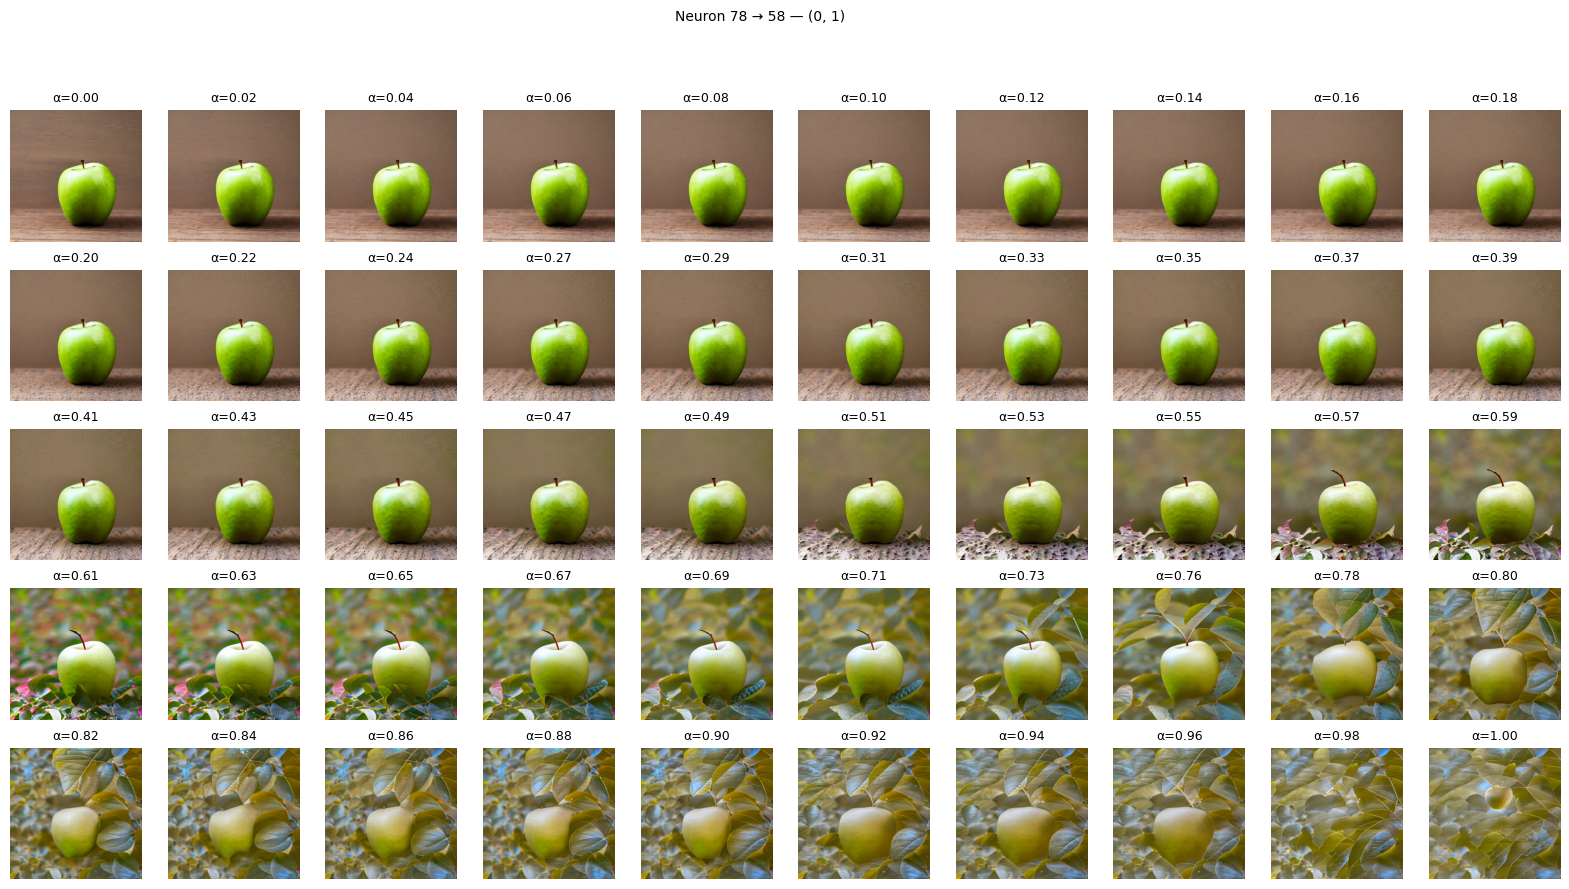

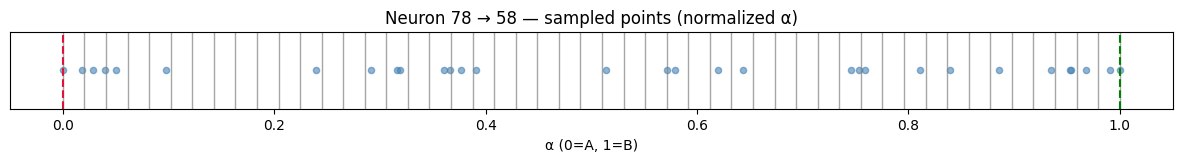

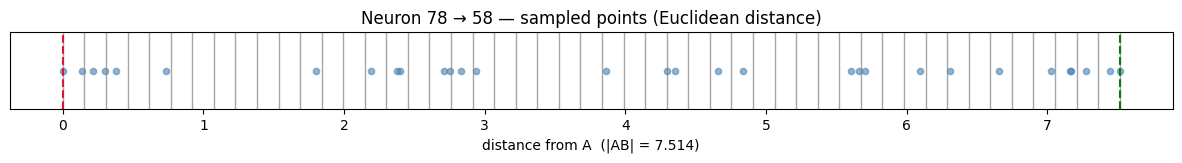

In [48]:
# 시각화
n_rows = int(np.ceil(N_SAMPLES / 10))
n_cols = min(N_SAMPLES, 10)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 2*n_rows))
if n_rows == 1: axes = np.array([axes])
axes = axes.flatten()
for idx, (ax, img, a) in enumerate(zip(axes, sample_images, sample_alphas)):
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(f'α={a:.2f}', fontsize=9) # 50*
for ax in axes[len(sample_images):]: ax.axis('off')
fig.suptitle(f'Neuron {j1} → {j2} — ({ALPHA_START}, {ALPHA_END})', fontsize=10)

# 교점 위치 표시 (정규화 α)
fig2, ax2 = plt.subplots(figsize=(15, 1))
ax2.scatter(alphas, np.zeros_like(alphas), s=20, color='steelblue', alpha=0.6)
for a in sample_alphas: ax2.axvline(a, color='grey', lw=1, alpha=0.7)
ax2.axvline(0, color='crimson', lw=1.5, linestyle='--')
ax2.axvline(1, color='green',   lw=1.5, linestyle='--')
ax2.set_xlim(-0.05, 1.05)
ax2.set_xlabel('α (0=A, 1=B)')
ax2.set_yticks([])
ax2.set_title(f'Neuron {j1} → {j2} — sampled points (normalized α)')
plt.show()

# 교점 위치 표시 (실제 거리)
sample_distances = sample_alphas * ab_len
fig3, ax3 = plt.subplots(figsize=(15, 1))
ax3.scatter(distances, np.zeros_like(distances), s=20, color='steelblue', alpha=0.6)
for d in sample_distances: ax3.axvline(d, color='grey', lw=1, alpha=0.7)
ax3.axvline(0,      color='crimson', lw=1.5, linestyle='--')
ax3.axvline(ab_len, color='green',   lw=1.5, linestyle='--')
margin = 0.05 * ab_len
ax3.set_xlim(-margin, ab_len + margin)
ax3.set_xlabel(f'distance from A  (|AB| = {ab_len:.3f})')
ax3.set_yticks([])
ax3.set_title(f'Neuron {j1} → {j2} — sampled points (Euclidean distance)')
plt.show()

In [22]:
print(f'|AB| = {AB.norm():.6f}')
print(f'shift at α=1.0 = {AB.norm():.6f}')
print(f'shift at α=0.5 = {(0.5 * AB).norm():.6f}')

|AB| = 7.514198
shift at α=1.0 = 7.514198
shift at α=0.5 = 3.757099


In [23]:
print(f'|h0| = {h0.norm():.3f}')
print(f'ratio = {AB.norm() / h0.norm():.6f}')

|h0| = 6.222
ratio = 1.207606
